## Descarga de dataset y preprocesamiento

In [1]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
import kagglehub
path = kagglehub.dataset_download("nih-chest-xrays/sample")

100%|██████████| 4.20G/4.20G [00:55<00:00, 80.9MB/s]

Extracting files...


In [3]:
data = pd.read_csv(f"{path}/sample_labels.csv")
data.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [4]:
def parse_age(age_str):
    if 'Y' in age_str:
        return int(age_str.replace('Y', ''))
    elif 'M' in age_str:
        return int(age_str.replace('M', '')) / 12
    elif 'D' in age_str:
        return int(age_str.replace('D', '')) / 365
    else:
        print(f"Formato de edad desconocido: {age_str}")
        return None

data['Age'] = data['Patient Age'].apply(parse_age)
data = data.drop('Patient Age', axis=1)
data.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y,Age
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,M,AP,3056,2544,0.139,0.139,60.0
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,M,AP,2500,2048,0.168,0.168,57.0
2,00000017_001.png,No Finding,1,17,M,AP,2500,2048,0.168,0.168,77.0
3,00000030_001.png,Atelectasis,1,30,M,PA,2992,2991,0.143,0.143,79.0
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,F,AP,2500,2048,0.168,0.168,55.0


In [5]:
data = data.drop(["Follow-up #", "Patient ID", "OriginalImageWidth", "OriginalImageHeight", "OriginalImagePixelSpacing_x", "OriginalImagePixelSpacing_y"], axis=1)
data.head()

,Image Index,Finding Labels,Patient Gender,View Position,Age
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,M,AP,60.0
1,00000013_026.png,Cardiomegaly|Emphysema,M,AP,57.0
2,00000017_001.png,No Finding,M,AP,77.0
3,00000030_001.png,Atelectasis,M,PA,79.0
4,00000032_001.png,Cardiomegaly|Edema|Effusion,F,AP,55.0


In [6]:
data = data[data['Age'] < 100]

In [7]:
data["Finding Labels"] = data["Finding Labels"].str.split('|')

mlb = MultiLabelBinarizer()
labels_df = pd.DataFrame(
    mlb.fit_transform(data["Finding Labels"]),
    columns=mlb.classes_,
    index=data.index
)

data = pd.concat([data, labels_df], axis=1)

In [8]:
data.drop("Finding Labels", axis=1, inplace=True)

In [9]:
print(data.head())

        Image Index Patient Gender View Position   Age  Atelectasis  \
0  00000013_005.png              M            AP  60.0            0   
1  00000013_026.png              M            AP  57.0            0   
2  00000017_001.png              M            AP  77.0            0   
3  00000030_001.png              M            PA  79.0            1   
4  00000032_001.png              F            AP  55.0            0   

   Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  Fibrosis  Hernia  \
0             0              0      0         0          1         0       0   
1             1              0      0         0          1         0       0   
2             0              0      0         0          0         0       0   
3             0              0      0         0          0         0       0   
4             1              0      1         1          0         0       0   

   Infiltration  Mass  No Finding  Nodule  Pleural_Thickening  Pneumonia  \
0             1 

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data['Patient Gender'] = data['Patient Gender'].apply(lambda x: 1 if x == 'M' else 0)
data['View Position'] = data['View Position'].apply(lambda x: 1 if x == 'PA' else 0)

scaler = StandardScaler()
data['Age'] = scaler.fit_transform(data['Age'].values.reshape(-1, 1))

# 3. Crear la columna objetivo para la Cabeza 1 (Normal/Anormal)
# Si 'No Finding' es True, entonces el paciente es 'Normal' (0)
# Si 'No Finding' es False, entonces tiene una patología, es 'Anormal' (1)
data['Anormal'] = (data['No Finding'] == False).astype(int)
data.drop('No Finding', axis=1, inplace=True)
data.head()

,Image Index,Patient Gender,View Position,Age,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Anormal
0,00000013_005.png,1,0,0.795327,0,0,0,0,0,1,0,0,1,0,0,1,0,1,1
1,00000013_026.png,1,0,0.615893,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
2,00000017_001.png,1,0,1.812124,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,00000030_001.png,1,1,1.931747,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,00000032_001.png,0,0,0.496270,0,1,0,1,1,0,0,0,0,0,0,0,0,0,1


## Ingeniería de características

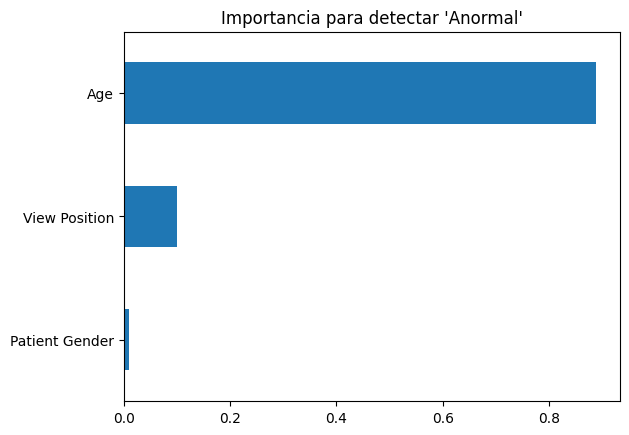

In [11]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

X = data[['Patient Gender', 'View Position', 'Age']]
y = data['Anormal']

model = RandomForestClassifier(random_state=42).fit(X, y)

pd.Series(model.feature_importances_, index=X.columns).sort_values().plot(kind='barh', title="Importancia para detectar 'Anormal'")
plt.show()